# Diabetes Classification

Phân loại bệnh tiểu đường bằng Machine Learning với **SVC** và **Random Forest**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 1. Load Dataset

Đọc dataset `diabetes.csv` và kiểm tra dữ liệu ban đầu.

In [2]:
data = pd.read_csv("diabetes.csv")
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


## 2. Exploratory Data Analysis (EDA)

Kiểm tra thông tin, thống kê mô tả, kích thước và giá trị thiếu của dataset.

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               29 non-null     int64  
 1   Glucose                   29 non-null     int64  
 2   BloodPressure             29 non-null     int64  
 3   SkinThickness             29 non-null     int64  
 4   Insulin                   29 non-null     int64  
 5   BMI                       29 non-null     float64
 6   DiabetesPedigreeFunction  29 non-null     float64
 7   Age                       29 non-null     int64  
 8   Outcome                   29 non-null     int64  
dtypes: float64(2), int64(7)
memory usage: 2.2 KB


In [4]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,4.517241,131.310345,70.000000,19.448276,91.965517,31.541379,0.455931,38.551724,0.517241
std,3.670546,35.230976,18.578021,17.678854,200.668256,8.310429,0.457257,13.265385,0.508548
min,0.000000,78.000000,0.000000,0.000000,0.000000,0.000000,0.134000,21.000000,0.000000
25%,1.000000,106.000000,64.000000,0.000000,0.000000,28.100000,0.201000,29.000000,0.000000
50%,4.000000,125.000000,72.000000,23.000000,0.000000,32.000000,0.315000,33.000000,1.000000
75%,8.000000,154.000000,78.000000,32.000000,94.000000,36.500000,0.443000,50.000000,1.000000
max,10.000000,197.000000,96.000000,48.000000,846.000000,44.000000,2.288000,66.000000,1.000000


In [5]:
data.shape

(29, 9)

In [6]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [7]:
'''
profile = ProfileReport(
    data,
    title="Diabetes Dataset Report",
    explorative=True
)

profile.to_file("diabetes_report.html")
'''

'\nprofile = ProfileReport(\n    data,\n    title="Diabetes Dataset Report",\n    explorative=True\n)\n\nprofile.to_file("diabetes_report.html")\n'

## 3. Define Features and Target

- **Features (X):** các biến đầu vào dùng để dự đoán.
- **Target (y):** `Outcome`, biến mục tiêu cần dự đoán.

In [8]:
target = "Outcome"
X = data.drop(target, axis=1)
y = data[target]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (29, 8)
y shape: (29,)


## 4. Split Dataset

Chia dữ liệu thành **Train / Validation / Test**.

- Test: 20%
- Phần còn lại: 80%
- Validation: 25% của 80% = 20% toàn bộ dữ liệu
- Train: 60% toàn bộ dữ liệu

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=100)

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    random_state=100
)


In [11]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (17, 8)
y_train: (17,)
X_val: (6, 8)
y_val: (6,)
X_test: (6, 8)
y_test: (6,)


## 5. Data Preprocessing

Sử dụng `StandardScaler` để chuẩn hóa các feature.

> Chỉ `fit` trên tập training để tránh **data leakage**. Validation và Test chỉ dùng `transform`.

In [12]:
scaler = StandardScaler()

In [13]:
X_train = scaler.fit_transform(X_train)

In [14]:
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## 6. Build Models

Xây dựng hai baseline models:

1. **SVC (Support Vector Classifier)**
2. **Random Forest Classifier**

In [15]:
# Pick models
svc_model = SVC()
rf_model = RandomForestClassifier(random_state=100)

## 7. Training

Huấn luyện các model bằng **training set**.

In [16]:
svc_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [17]:
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",100
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

## 8. Validation Evaluation

Đánh giá model trên **validation set** trước khi đánh giá cuối cùng trên test set.

In [18]:
y_val_pred_svc = svc_model.predict(X_val)
y_val_pred_rf = rf_model.predict(X_val)

In [19]:
print("===== SVC - Validation =====")
print("Accuracy :", accuracy_score(y_val, y_val_pred_svc))
print("Precision:", precision_score(y_val, y_val_pred_svc))
print("Recall   :", recall_score(y_val, y_val_pred_svc))
print("F1 Score :", f1_score(y_val, y_val_pred_svc))

===== SVC - Validation =====
Accuracy : 0.6666666666666666
Precision: 0.5
Recall   : 0.5
F1 Score : 0.5


In [20]:
print("===== Random Forest - Validation =====")
print("Accuracy :", accuracy_score(y_val, y_val_pred_rf))
print("Precision:", precision_score(y_val, y_val_pred_rf))
print("Recall   :", recall_score(y_val, y_val_pred_rf))
print("F1 Score :", f1_score(y_val, y_val_pred_rf))

===== Random Forest - Validation =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [21]:
print("===== SVC - Validation =====")
print(classification_report(y_val, y_val_pred_svc))

===== SVC - Validation =====
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.50      0.50      0.50         2

    accuracy                           0.67         6
   macro avg       0.62      0.62      0.62         6
weighted avg       0.67      0.67      0.67         6



In [22]:
print("===== Random Forest - Validation =====")
print(classification_report(y_val, y_val_pred_rf))

===== Random Forest - Validation =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



## 9. Test Evaluation

Đánh giá cuối cùng trên **test set** sau khi hoàn thành bước validation.

In [23]:
y_test_pred_svc = svc_model.predict(X_test)
y_test_pred_rf = rf_model.predict(X_test)

In [24]:
print("===== SVC - Test =====")
print("Accuracy :", accuracy_score(y_test, y_test_pred_svc))
print("Precision:", precision_score(y_test, y_test_pred_svc))
print("Recall   :", recall_score(y_test, y_test_pred_svc))
print("F1 Score :", f1_score(y_test, y_test_pred_svc))

===== SVC - Test =====
Accuracy : 0.8333333333333334
Precision: 0.75
Recall   : 1.0
F1 Score : 0.8571428571428571


In [25]:
print(classification_report(y_test, y_test_pred_svc))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.75      1.00      0.86         3

    accuracy                           0.83         6
   macro avg       0.88      0.83      0.83         6
weighted avg       0.88      0.83      0.83         6



In [26]:
print("===== Random Forest - Test =====")
print("Accuracy :", accuracy_score(y_test, y_test_pred_rf))
print("Precision:", precision_score(y_test, y_test_pred_rf))
print("Recall   :", recall_score(y_test, y_test_pred_rf))
print("F1 Score :", f1_score(y_test, y_test_pred_rf))

===== Random Forest - Test =====
Accuracy : 0.6666666666666666
Precision: 0.6666666666666666
Recall   : 0.6666666666666666
F1 Score : 0.6666666666666666


## 10. Confusion Matrix — SVC

Ma trận nhầm lẫn của SVC trên test set.

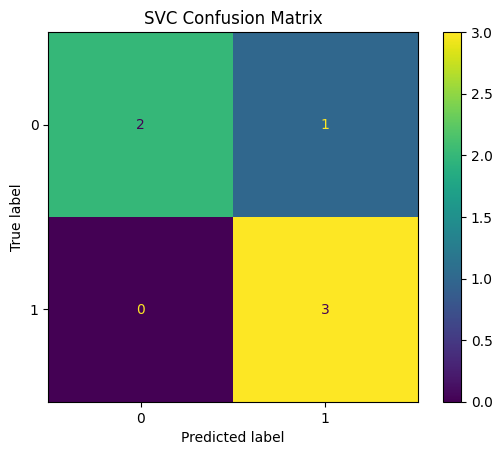

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred_svc)
plt.title("SVC Confusion Matrix")
plt.show()

In [28]:
cm_svc=confusion_matrix(y_test,y_test_pred_svc)
TN,FP,FN,TP=cm_svc.ravel()
print("TN-Số lượng người không bị bệnh và model đoán đúng là không bị bệnh =",TN)
print("FP-Số lượng người không mắc bệnh nhưng mô hình dự đoán có bệnh =",FP)
print("FN-Số lượng người mắc bệnh nhưng mô hình dự đoán không có bệnh =",FN)
print("TP-Số lượng người mắc bệnh và model đoán đúng là có bệnh =",TP)


TN-Số lượng người không bị bệnh và model đoán đúng là không bị bệnh = 2
FP-Số lượng người không mắc bệnh nhưng mô hình dự đoán có bệnh = 1
FN-Số lượng người mắc bệnh nhưng mô hình dự đoán không có bệnh = 0
TP-Số lượng người mắc bệnh và model đoán đúng là có bệnh = 3


## 11. Confusion Matrix — Random Forest

Ma trận nhầm lẫn của Random Forest trên test set.

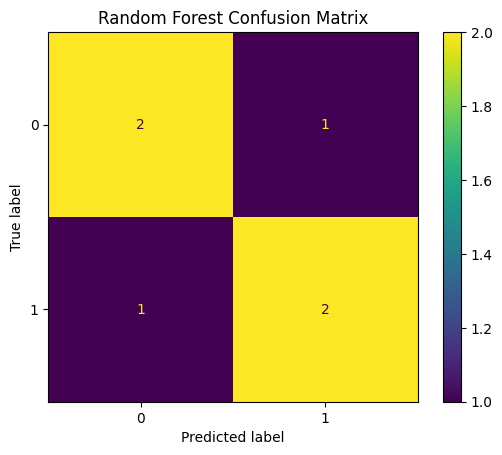

In [29]:
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [30]:
cm_rf=confusion_matrix(y_test,y_test_pred_rf)
TN,FP,FN,TP=cm_rf.ravel()
print("TN-Số lượng người không bị bệnh và model đoán đúng là không bị bệnh =",TN)
print("FP-Số lượng người không mắc bệnh nhưng mô hình dự đoán có bệnh =",FP)
print("FN-Số lượng người mắc bệnh nhưng mô hình dự đoán không có bệnh =",FN)
print("TP-Số lượng người mắc bệnh và model đoán đúng là có bệnh =",TP)

TN-Số lượng người không bị bệnh và model đoán đúng là không bị bệnh = 2
FP-Số lượng người không mắc bệnh nhưng mô hình dự đoán có bệnh = 1
FN-Số lượng người mắc bệnh nhưng mô hình dự đoán không có bệnh = 1
TP-Số lượng người mắc bệnh và model đoán đúng là có bệnh = 2


## 12. Model Comparison

So sánh Accuracy, Precision, Recall và F1 Score của hai model.

In [31]:
results = pd.DataFrame({
    "Model": ["SVC", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_test_pred_svc),
        accuracy_score(y_test, y_test_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_test_pred_svc),
        precision_score(y_test, y_test_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_test_pred_svc),
        recall_score(y_test, y_test_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_test_pred_svc),
        f1_score(y_test, y_test_pred_rf)
    ]
})
results

,Model,Accuracy,Precision,Recall,F1
0,SVC,0.833333,0.750000,1.000000,0.857143
1,Random Forest,0.666667,0.666667,0.666667,0.666667
